In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [3]:
# Load Dataset
df = pd.read_csv("first inten project.csv")


In [4]:
# Data Overview
print("Dataset Overview:\n", df.head())



Dataset Overview:
   Booking_ID  number of adults  number of children  number of weekend nights  \
0   INN00001                 1                   1                         2   
1   INN00002                 1                   0                         1   
2   INN00003                 2                   1                         1   
3   INN00004                 1                   0                         0   
4   INN00005                 1                   0                         1   

   number of week nights  type of meal  car parking space    room type  \
0                      5   Meal Plan 1                  0  Room_Type 1   
1                      3  Not Selected                  0  Room_Type 1   
2                      3   Meal Plan 1                  0  Room_Type 1   
3                      2   Meal Plan 1                  0  Room_Type 1   
4                      2  Not Selected                  0  Room_Type 1   

   lead time market segment type  repeated  P-C  P-not-

In [ ]:
print("\nData Info:")
df.info()

In [ ]:
print("\nMissing Values:")
print(df.isnull().sum())

In [5]:
# Drop unnecessary columns (Booking_ID, date of reservation)
df.drop(columns=['Booking_ID', 'date of reservation'], inplace=True)


In [6]:
# Encode categorical variables
label_encoders = {}
categorical_cols = ['type of meal', 'room type', 'market segment type', 'booking status']
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

In [7]:
# Define Features and Target
X = df.drop(columns=['booking status'])
y = df['booking status']

In [8]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


In [9]:
# Feature Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [10]:
# Train an SVM Model with Balanced Class Weights
svm = SVC(kernel='rbf', class_weight='balanced', probability=True, random_state=42)
svm.fit(X_train, y_train)


SVC(class_weight='balanced', probability=True, random_state=42)

In [11]:
# Predictions
y_pred = svm.predict(X_test)

In [12]:
# Model Evaluation
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)
print("Classification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.8052914427449359
Classification Report:
               precision    recall  f1-score   support

           0       0.67      0.80      0.73      2378
           1       0.89      0.81      0.85      4879

    accuracy                           0.81      7257
   macro avg       0.78      0.80      0.79      7257
weighted avg       0.82      0.81      0.81      7257



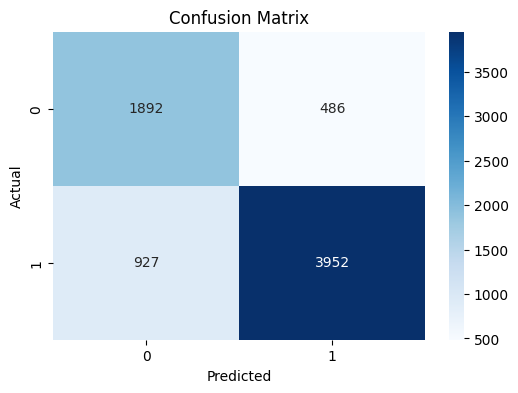

In [13]:
# Confusion Matrix
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()